In [3]:
import numpy as np

In [4]:
run_dir = '/Users/akap5486/Projects/groundwater/data/henry_data/one_coupling_scenario/scenario_beta0.200_diffc0.00140/run_000001_hk864.00_por0.350_in2.8510_ghb1.0000'

In [5]:
windows = np.load(run_dir + '/windows.npz')
windows.files

['input_tensor',
 'output_tensor',
 'input_channel_names',
 't_index',
 't_lag_index',
 'time_t',
 'time_t_lag',
 'window_ids',
 'lag',
 'ncol',
 'nlay',
 'total_time',
 'nstp',
 'beta_c',
 'diffc',
 'hk',
 'por',
 'inflow',
 'ghb_head',
 'al',
 'at',
 'cinlet',
 'init_mode',
 'initial_head',
 'initial_concentration']

In [6]:
windows['input_tensor'].shape, windows['output_tensor'].shape

((49, 8, 40, 80), (49, 2, 40, 80))

In [10]:
# Plot conc and head at the first time step of the input tensor
import matplotlib.pyplot as plt
def plot_input_output_at_idx(windows, idx=0):
    input_tensor = windows['input_tensor']
    channel_names = windows['input_channel_names']

    # Decode channel names if stored as bytes
    channel_names = [
        name.decode('utf-8') if isinstance(name, (bytes, np.bytes_)) else str(name)
        for name in channel_names
    ]

    n_channels = input_tensor.shape[1]
    n_cols = min(3, n_channels)
    n_rows = int(np.ceil(n_channels / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ch in range(n_channels):
        if ch == 0:
            cmap = 'Reds'
        elif ch == 1:
            cmap = 'Blues'
        else:
            cmap = 'Greens'
        im = axes[ch].imshow(input_tensor[idx, ch, :, :], origin='upper', cmap=cmap)
        axes[ch].set_title(channel_names[ch] if ch < len(channel_names) else f'Channel {ch}')
        fig.colorbar(im, ax=axes[ch])

    # Hide any unused subplot axes
    for k in range(n_channels, len(axes)):
        axes[k].axis('off')

    plt.tight_layout()
    plt.show()


    fig, ax = plt.subplots(1, 2, figsize=(7, 2))

    im0 = ax[0].imshow(windows['output_tensor'][idx, 0, :, :], origin='upper', cmap='Reds')
    ax[0].set_title('Concentration')
    fig.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(windows['output_tensor'][idx, 1, :, :], origin='upper', cmap='Blues')
    ax[1].set_title('Head')
    fig.colorbar(im1, ax=ax[1])

    plt.tight_layout()
    plt.show()

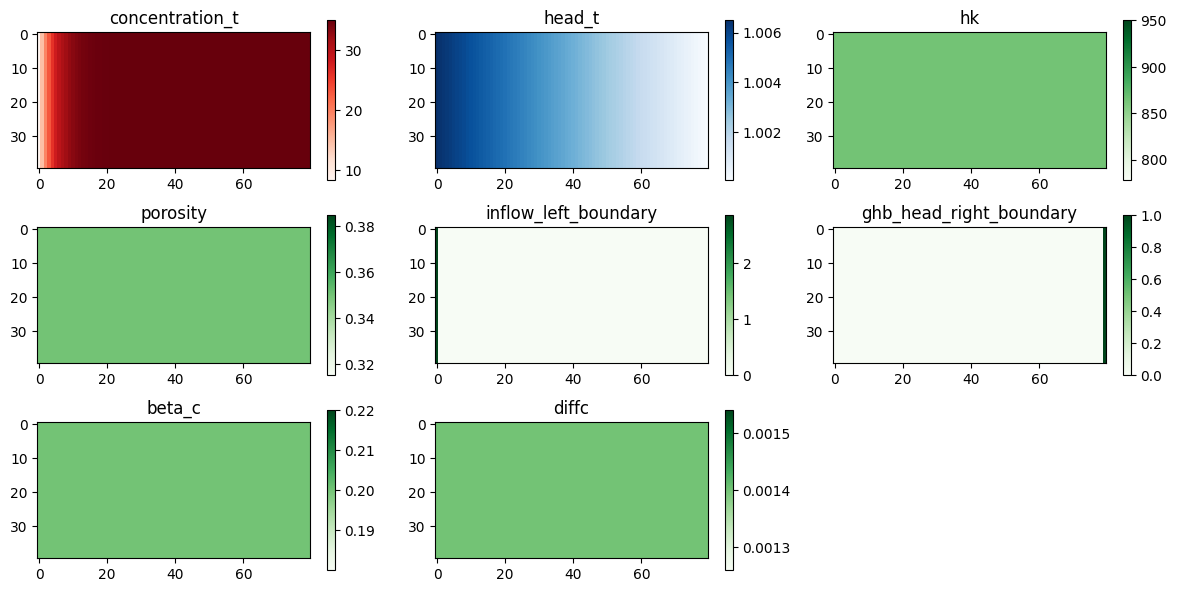

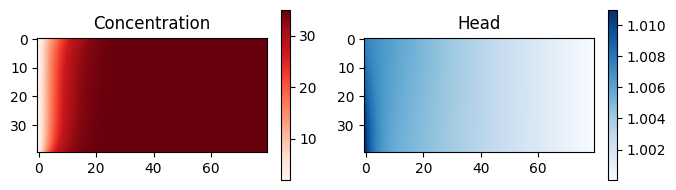

In [11]:
plot_input_output_at_idx(windows, idx=0)

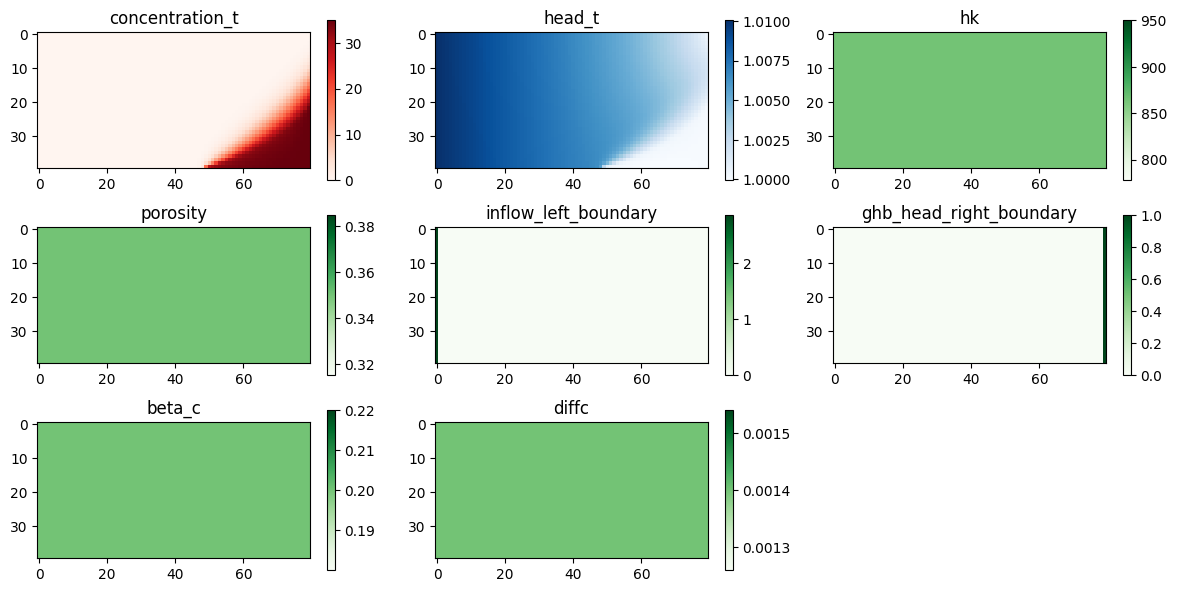

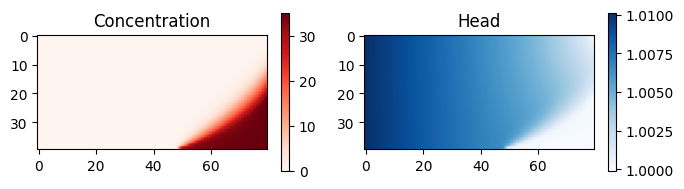

In [12]:
plot_input_output_at_idx(windows, idx=-1)